In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [5]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [6]:
len(words)

32033

In [7]:
t = words
chrs = sorted(list(set(''.join(t))))
stoi = {}
itos = {}
for i,ch in enumerate(chrs):
    stoi[ch] = i+1
    itos[i+1] = ch

stoi['.'] = 0
itos[0] = '.'


In [8]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


### Task 1: Setup and Data Preprocessing
- Before building the neural network, you need to prepare the character vocabulary and structure your rolling context window.

- Imports: Import torch and matplotlib.pyplot.

- Read the Data: Load your dataset of names (e.g., names.txt) into a list of strings (words).

- Build the Vocabulary: Create a sorted list of unique characters (including a special . token for padding/end-of-word).

- Mapping Dictionaries: Build lookup tables to convert characters to integers (stoi) and vice versa (itos).

- Define block_size: Set your context length hyperparameter (start with block_size = 3 to match the Bengio et al. 2003 paper).

- Create the Rolling Window Dataset: Write a function to iterate through the words. For each word, use a sliding window of size block_size to build your input array X (context indices) and label array Y (index of the target next character).

In [175]:
# lets define block_size = k, the number of characters that would feed into this neural network.
block_size = 3

# Rolling window dataset: 
context = [stoi['.']] *  block_size
X, Y  = [], []

for w in words[:10]:
    chrs = list(w) + ['.']
    for ch in chrs:
        #print(context, ch)
        X.append(context)
        Y.append(stoi[ch])
        context = context[1:] + [stoi[ch]]
# for x, y in zip(X, Y):
#     print(''.join([itos[k] for k in x]), itos[y])

Xt, Yt = torch.tensor(X), torch.tensor(Y)


### Task 2: Parameter Initialization
- Initialize your network parameters manually using a random number generator for reproducibility.
- Embedding Lookup Table ($C$): Initialize a random tensor of shape (27, embedding_dim). Start with embedding_dim = 2 for visualization purposes.
- Hidden Layer ($W_1, b_1$): Initialize the weights and biases for the hidden layer. The input size will be block_size * embedding_dim. Start with 300 hidden neurons.
- Output Layer ($W_2, b_2$): Initialize weights and biases to project from the hidden layer size (300) back to the vocabulary size (27).
- Enable Gradients: Wrap all parameter tensors in a list and explicitly set p.requires_grad = True for each one.

In [25]:
g = torch.Generator().manual_seed(2147483647)

# Hyperparams:
vocab_size = len(itos) # 27
embed_dim = 2 # start with 2 for visualization purposes. 

# Embedding lookup table C
C = torch.randn((vocab_size, embed_dim))


In [32]:
# Hidden layer
# hidden layer hyper params
w1_size = 100 # 100 neurons
b1_size = 100
W1 = torch.randn((block_size * embed_dim, w1_size))
B1 = torch.randn(b1_size)
print(W1.shape, B1.shape)

W2 = torch.randn((W1.shape[1], vocab_size))
B2 = torch.randn(vocab_size)
W2.shape, B2.shape
parameters = [C, W1, B1, W2, B2]


torch.Size([6, 100]) torch.Size([100])


In [40]:
[(len(p), p.nelement()) for p in parameters]
(len(C), C.nelement())

for p in parameters:
    p.requires_grad = True

### Task 3: Implement the Forward Pass
- Manually code the matrix operations to pass data through your network.
- Embed Inputs: Retrieve the character embeddings using direct indexing: emb = C[X].
- Flatten/Concatenate: Transform the multi-dimensional embedding tensor into a 2D tensor of shape (num_examples, block_size * embedding_dim). Tip: Use emb.view(-1, block_size * embedding_dim) for efficiency instead of torch.cat or torch.unbind.
- Hidden Activation: Compute the hidden layer linear combination and apply the torch.tanh non-linearity.
- Logits & Cross Entropy Loss: Compute the output logits. Instead of writing your own softmax normalization, pass the logits and target labels directly into PyTorch's torch.nn.functional.cross_entropy(logits, Y).

In [59]:
emb  = C[Xt]

In [72]:
for d in torch.unbind(emb, 1):
    print(d.shape)

torch.Size([67, 2])
torch.Size([67, 2])
torch.Size([67, 2])


In [130]:
a = torch.arange(18)
b = a.view(3, 3, 2)
print(b)
c = torch.unbind(b, 1)
torch.cat(c, 1)



tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])


tensor([2, 9])

In [109]:
h = torch.tanh(emb.view(-1, 6) @ W1 + B1)
logits = h @ W2 + B2


In [143]:
c =  logits.exp()
probs = c / c.sum(1, keepdims=True)
probs.shape
loss = -probs[torch.arange(probs.shape[0]), Yt].log().mean()
loss


tensor(12.7486, grad_fn=<NegBackward0>)

In [144]:
torch.nn.functional.cross_entropy(logits, Yt)

tensor(12.7486, grad_fn=<NllLossBackward0>)

In [249]:
## Respectable concise version: 
# Declaration: 

g = torch.Generator().manual_seed(2147483647)

# Hyperparams:
vocab_size = len(itos) # 27
embed_dim = 2 # start with 2 for visualization purposes. 

# Embedding lookup table C
C = torch.randn((vocab_size, embed_dim))

# hidden layer hyper params
w1_size = 100 # 100 neurons
b1_size = 100
W1 = torch.randn((block_size * embed_dim, w1_size))
B1 = torch.randn(b1_size)
print(W1.shape, B1.shape)

W2 = torch.randn((W1.shape[1], vocab_size))
B2 = torch.randn(vocab_size)
parameters = [C, W1, B1, W2, B2]

# requires grad
for p in parameters:
    p.requires_grad = True




torch.Size([6, 100]) torch.Size([100])


In [288]:
# Dataset creation.
# lets define block_size = k, the number of characters that would feed into this neural network.
block_size = 3

def build_dataset(words):
    # Rolling window dataset: 
    context = [stoi['.']] *  block_size
    X, Y  = [], []
    
    for w in words[:]:
        chrs = list(w) + ['.']
        for ch in chrs:
            #print(context, ch)
            X.append(context)
            Y.append(stoi[ch])
            context = context[1:] + [stoi[ch]]
    # for x, y in zip(X, Y):
    #     print(''.join([itos[k] for k in x]), itos[y])
    
    Xt, Yt = torch.tensor(X), torch.tensor(Y)
    return Xt, Yt

Xt, Yt = build_dataset(words)


In [250]:
batch_size = 32

lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre


In [277]:
lossi = []
stepi= []
lri = []

In [278]:
# Forward pass

for i in range(10000):
    ix = torch.randint(0, Xt.shape[0], (batch_size, ))
    emb  = C[Xt[ix]]
    h = torch.tanh(emb.view(-1, 6) @ W1 + B1)
    logits = h @ W2 + B2
    
    c =  logits.exp()
    probs = c / c.sum(1, keepdims=True)
    # probs.shape
    # loss = -probs[torch.arange(probs.shape[0]), Yt].log().mean()
    loss = torch.nn.functional.cross_entropy(logits, Yt[ix])
    
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Gradient descent update
    #lr = lrs[i]
    #lri.append(lr)
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #print(loss.item())
    lossi.append(loss.item())
    stepi.append(i)

# much better to have an approximate gradient and take more steps than an exact gradient and take fewer steps.
print(lossi[-1])

2.008453607559204


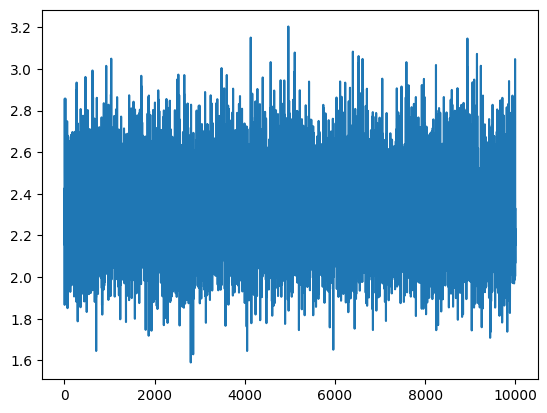

In [280]:
import numpy as np
plt.plot(stepi, lossi)
#sum([p.nelement() for p in parameters])
print(lossi[-1])

### Task 4: Implement Mini-Batch Training
- To make training efficient over thousands of examples, implement a training loop that steps on small random slices of data.
- Create the Optimization Loop: Set up a loop for a few thousand iterations.
- Construct Mini-Batches: In each iteration, use torch.randint to pick a random batch of indices (e.g., batch_size = 32). Index into your full X and Y datasets to get Xb and Yb.
- Backward Pass & Update:
  * Reset your gradients (p.grad = None).
  * Compute the loss on the mini-batch and call loss.backward().
  * Update the data for each parameter using a standard learning rate step: p.data += -learning_rate * p.grad.

In [281]:
# Compute loss on the whole dataset (and not just the mini-batch)
emb = C[Xt]
h = torch.tanh(emb.view(-1, 6) @ W1 + B1)
logits = h @ W2 + B2
loss = torch.nn.functional.cross_entropy(logits, Yt)
print(loss)

tensor(2.3226, grad_fn=<NllLossBackward0>)


![the neural network](nn_2.png)

##Task 5: Learning Rate Finding & Diagnostics
Instead of guessing a learning rate, implement a diagnostic search to find the sweet spot.
- Learning Rate Search: Create a linear space of exponents using torch.linspace(-3, 0, 1000) and convert them to actual learning rates via 10lre. Run 1,000 steps tracking the learning rate used and the resulting batch loss.

- Plot the Loss: Use matplotlib to plot the learning rate exponents against the losses to identify the "valley" where the network learns stably without exploding.

- Evaluate Full Splits: Calculate your true loss over the entire dataset at regular intervals, rather than relying strictly on noisy mini-batch loss tracking.

### Task 6: Data Splitting (Train / Dev / Test)
To protect your model against memorization and overfitting, separate your dataset structurally.

- Shuffle and Split: Shuffle your words list randomly. Split the words into three distinct sets: 80% for Training, 10% for Dev/Validation, and 10% for Testing.

- Update the Pipeline: Generate separate X and Y tensors for each split (Xtrain, Ytrain, Xdev, Ydev, Xtest, Ytest).

- Train and Validate: Train the model parameters only on the training split, and evaluate your hyperparameter performance using the dev split.

### Task 7: Vector Space Visualization
If you are using a 2D embedding space (embedding_dim = 2), write a diagnostic visualization function.

- Plot the Embeddings: Use plt.scatter to plot the 2D coordinates for all 27 characters.

- Annotate: Label each point with its respective string character using plt.text. Observe how the trained network naturally clusters structural features (such as grouping vowels together).

### Task 8: Sampling from the Model
Write the generation script to watch your trained network output completely new names.

- Initialize Context: Begin your sampling loop with a fully padded context window of dots (.).

- Generate Next Character: Feed the context window forward through your embedding table and model layers to get current logits.

- Softmax: Convert logits into a proper probability distribution using torch.nn.functional.softmax(logits, dim=1).

- Sample: Use torch.multinomial to sample a single character index from that distribution. Append the new character index to your running name string and slide your context window to include it. Loop until you sample the end-of-word . token.

In [358]:
# Dataset creation with dataset split
# lets define block_size = k, the number of characters that would feed into this neural network.
block_size = 3

def build_dataset(words):
    # Rolling window dataset: 
    context = [stoi['.']] *  block_size
    X, Y  = [], []
    
    for w in words[:]:
        chrs = list(w) + ['.']
        for ch in chrs:
            #print(context, ch)
            X.append(context)
            Y.append(stoi[ch])
            context = context[1:] + [stoi[ch]]
    # for x, y in zip(X, Y):
    #     print(''.join([itos[k] for k in x]), itos[y])
    
    Xt, Yt = torch.tensor(X), torch.tensor(Y)
    return Xt, Yt

# random shuffle
import random
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtrain, Ytrain = build_dataset(words[:n1])
Xvd, Yvd = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

In [359]:
## Respectable concise version: 
# Declaration: 

g = torch.Generator().manual_seed(2147483647)

# Hyperparams:
vocab_size = len(itos) # 27
embed_dim = 10 # start with 2 for visualization purposes. 

# Embedding lookup table C
C = torch.randn((vocab_size, embed_dim))

# hidden layer hyper params
w1_size = 200 # 300 neurons
b1_size = 200
W1 = torch.randn((block_size * embed_dim, w1_size))
B1 = torch.randn(b1_size)
print(W1.shape, B1.shape)

W2 = torch.randn((W1.shape[1], vocab_size))
B2 = torch.randn(vocab_size)
parameters = [C, W1, B1, W2, B2]

# requires grad
for p in parameters:
    p.requires_grad = True

sum(p.nelement() for p in parameters)


torch.Size([30, 200]) torch.Size([200])


11897

In [360]:
batch_size = 32

lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre


In [361]:
lossi = []
stepi= []
lri = []

In [369]:
# Forward pass

input_vector_size = block_size * embed_dim
for i in range(50000):
    ix = torch.randint(0, Xtrain.shape[0], (batch_size, ))
    emb  = C[Xtrain[ix]]
    h = torch.tanh(emb.view(-1, input_vector_size) @ W1 + B1)
    logits = h @ W2 + B2
    
    c =  logits.exp()
    probs = c / c.sum(1, keepdims=True)
    # probs.shape
    # loss = -probs[torch.arange(probs.shape[0]), Yt].log().mean()
    loss = torch.nn.functional.cross_entropy(logits, Ytrain[ix])
    
    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # Gradient descent update
    #lr = lrs[i]
    #lri.append(lr)
    lr = 0.1 if i < 100000 else 0.01
    # lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #print(loss.item())
    lossi.append(loss.log10().item())
    stepi.append(i)

# much better to have an approximate gradient and take more steps than an exact gradient and take fewer steps.
print(10**lossi[-1])

0.4030390679836273


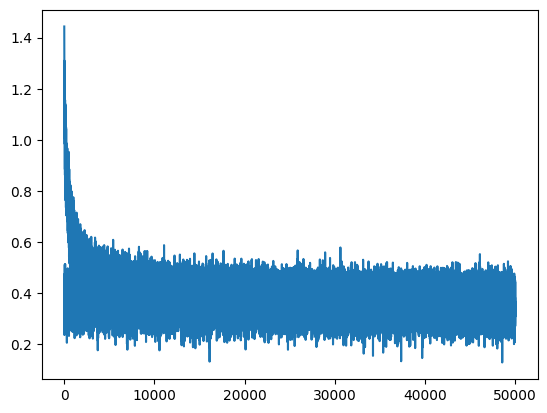

In [368]:
plt.plot(stepi, lossi)

In [370]:
# Compute loss on the whole dataset (and not just the mini-batch)
emb = C[Xtrain]
h = torch.tanh(emb.view(-1, input_vector_size) @ W1 + B1)
logits = h @ W2 + B2
loss = torch.nn.functional.cross_entropy(logits, Ytrain)
print(loss)

emb = C[Xvd]
h = torch.tanh(emb.view(-1, input_vector_size) @ W1 + B1)
logits = h @ W2 + B2
loss = torch.nn.functional.cross_entropy(logits, Yvd)
print(loss)

tensor(2.1420, grad_fn=<NllLossBackward0>)
tensor(2.1626, grad_fn=<NllLossBackward0>)


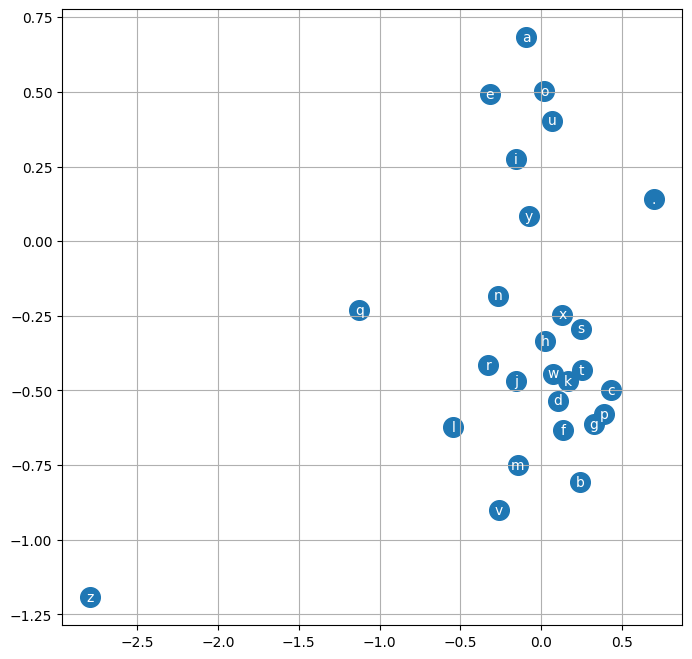

In [355]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [401]:
# sample from the neural net
g = torch.Generator().manual_seed(2147483647)
def generate():
    out = []
    context = [stoi['.']] * block_size
    while True:
        emb = C[context]
        # context, emb.shape, C.shape, input_vector_size
        emb.view(-1, input_vector_size).shape
        #forward pass
        h = torch.tanh(emb.view(-1, input_vector_size) @ W1 + B1)
        logits = h @ W2 + B2
        logits = logits.exp()
        probs = logits / logits.sum(1, keepdims=True)
        # print(probs)
        samples = torch.multinomial(probs, 1, replacement=True, generator=g)
        # loss = torch.nn.functional.cross_entropy(logits, Ytrain)
        # print(loss)
        item = samples.item()
        out.append(itos[item])
        context = context[1:] + [item]
        # print(''.join(out))
        if item == 0:
            break
    return out

for _ in range(20):
    out = generate()
    print(''.join(out))

her.
mariah.
mrkion.
vayden.
maimitta.
vra.
van.
han.
harleighukphahrighton.
moriella.
ovie.
quda.
valey.
maside.
hakaviyah.
qubstohlynn.
hatallys.
qusdra.
quenleryan.
vran.


In [21]:
# Why to use F.cross_entropy() instead of exp() / sum and -log prob. Combining the mathematical operations into a single
# fused kernel makes forward/ backward passed more efficient. Also pytorch handles very large values exp(100) very well
# by subtracting the largest value out. 

In [22]:
# empirically derive the learning rate.

In [ ]:
# why splits ? otherwise it'll overfit the entire training dataset.
# hyperparameters are the sizes of hidden layers, which determine the total number of parameters.
# size of embedding.
# try many variations of hyperparameters on validation set. thats the goal of the validation set. 